In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from scipy import stats
from scipy.stats import f_oneway
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("C:/Users/Sravya Ventrapragada/Documents/pls/takehome_sravya/askscience_data.csv")
data.drop('Unnamed: 0', axis = 1, inplace=True)
data['datetime'] = pd.to_datetime(data['datetime'])
data.columns

Index(['title', 'body', 'tag', 'datetime', 'author', 'score', 'upvote_ratio',
       'url'],
      dtype='object')

In [2]:
# Check for NaN values in the score column
print(data['score'].isna().sum()) 

0


In [3]:
# Reading the data and details of the columns
print(data.info())

# Check for missing values
print(data.isnull().sum())

# check for duplicates if any
print(data.shape)
data = data.drop_duplicates()
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4205 entries, 0 to 4204
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         4205 non-null   object        
 1   body          2492 non-null   object        
 2   tag           4011 non-null   object        
 3   datetime      4205 non-null   datetime64[ns]
 4   author        4205 non-null   object        
 5   score         4205 non-null   float64       
 6   upvote_ratio  4205 non-null   float64       
 7   url           4205 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 262.9+ KB
None
title              0
body            1713
tag              194
datetime           0
author             0
score              0
upvote_ratio       0
url                0
dtype: int64
(4205, 8)
(4169, 8)


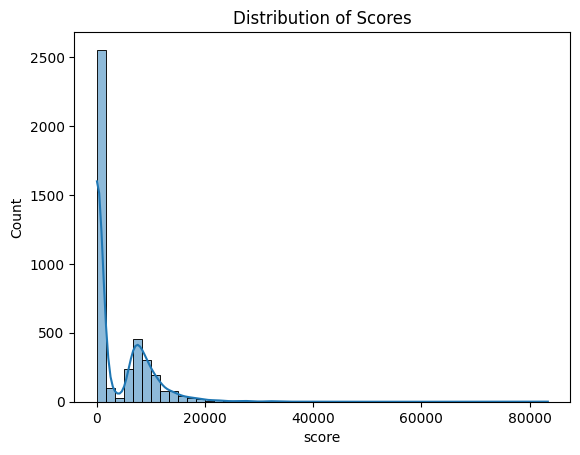

In [4]:
# Distribution of post scores
sns.histplot(data['score'], bins=50, kde=True)
plt.title("Distribution of Scores")
plt.show()

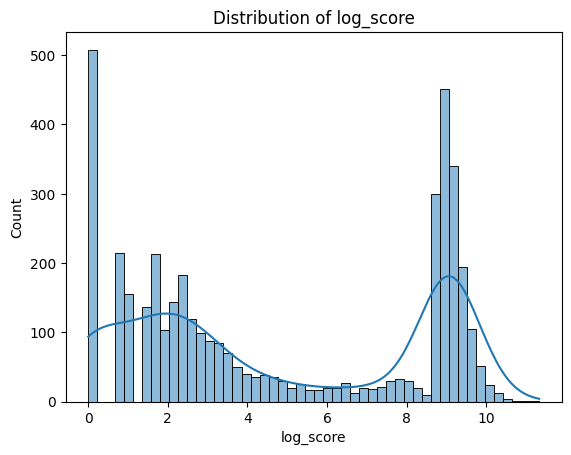

In [5]:
# Since the scores data is skewed, applying log-transform to the column
data["log_score"] = np.log1p(data['score'])  # log1p avoids log(0) issues

sns.histplot(data['log_score'], bins=50, kde=True)
plt.title("Distribution of log_score")
plt.show()

In [6]:
# This plot indicates big spike at log_score = 0, which means many posts have a very less score. The next peak between 8-10 indicates the posts that 
# went viral which might have received lot of upvotes. Now with the log tranform the spread is more even and easier to analyze. This also suggest a 
# binomial distribution one group which has no engagement/upvotes(low log_score/unsuccessful) and other significant engagement(high log_score, succesful).

# From the plots based on the elbow method, we can see a natural break in data  log_score between 5-7. So setting log_score cutoff at 6.
# Low engagement: log_score < 6
# High engagement: log_score ≥ 6

# based on set cutoff dividing the data and understand the word cloud of title.

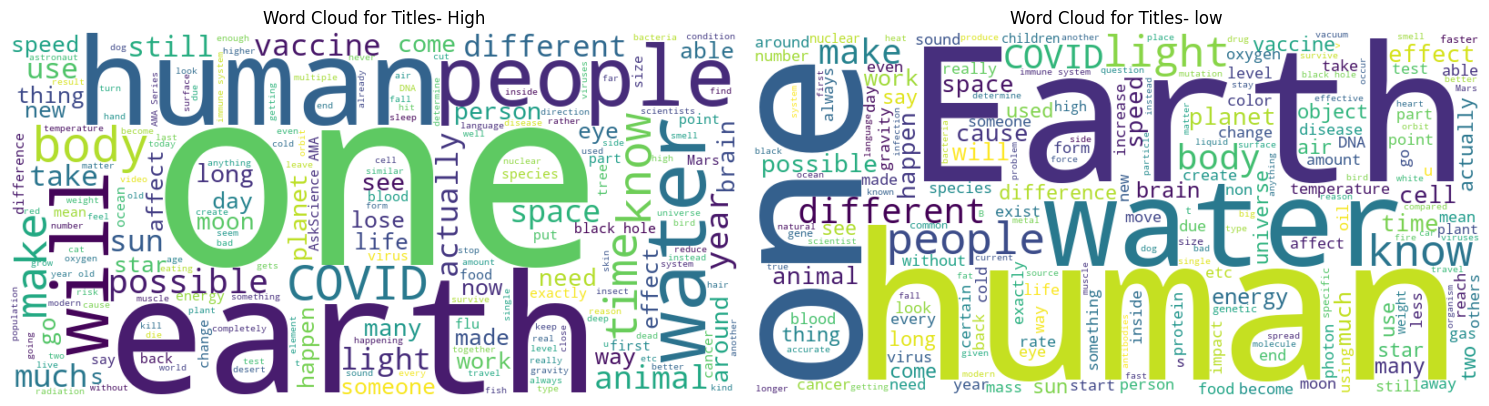

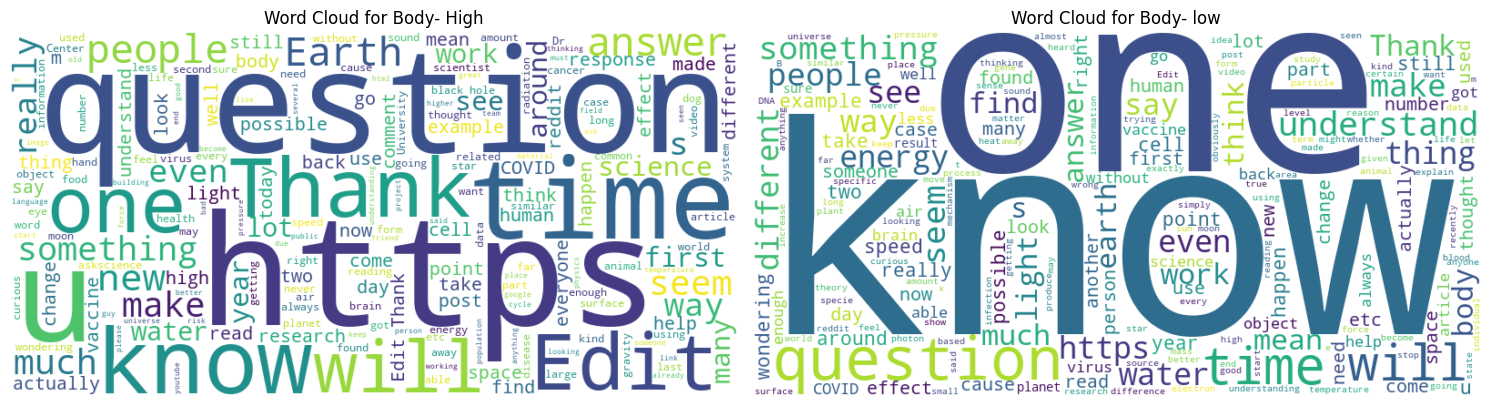

In [7]:
# Create high and low engagement data subset

data['title_modified'] = data['title'].fillna("")
data['body_modified'] = data['body'].fillna("")

threshold = 1000
high_engagement = data[data['score'] >= threshold]
low_engagement = data[data['score'] < threshold]

high_title_text = " ".join(high_engagement['title_modified'])
low_title_text = " ".join(low_engagement['title_modified'])

high_body_text = " ".join(high_engagement['body_modified'])
low_body_text = " ".join(low_engagement['body_modified'])


# Function to generate and display a word cloud
def plot_wordcloud(text1, text2, title):
    wordcloud1 = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(text1)
    wordcloud2 = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(text2)
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(wordcloud1, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(title + '- High')

    axes[1].imshow(wordcloud2, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(title + '- low')
    plt.tight_layout()
    plt.show() 

plot_wordcloud(high_title_text, low_title_text, "Word Cloud for Titles")

plot_wordcloud(high_body_text, low_body_text, "Word Cloud for Body")

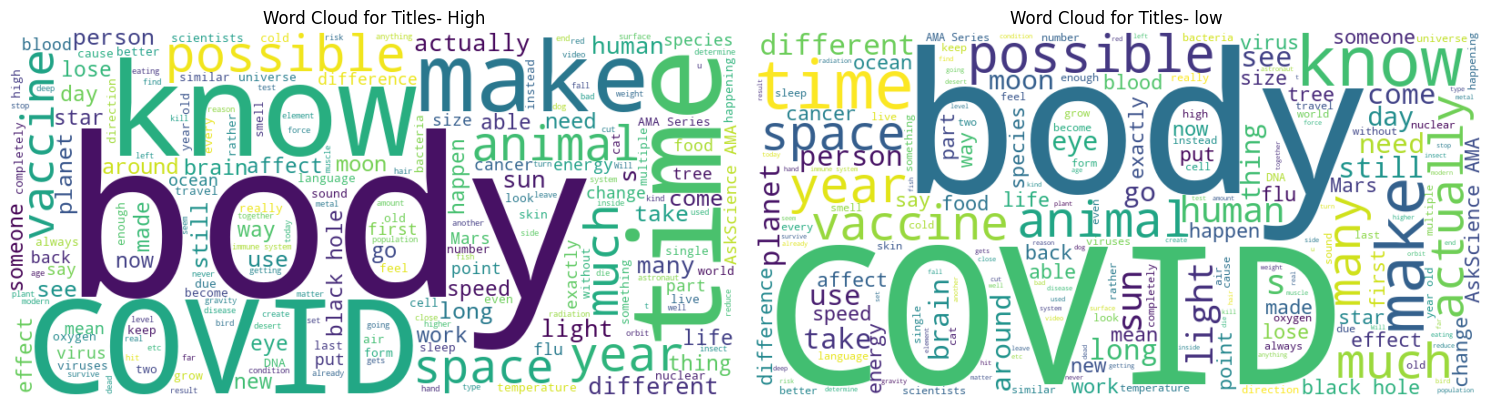

In [8]:
# Removing some of the most frequent words from titles to understand if there are any other significant titles.
words_to_remove = ['one', 'human', 'earth', 'Earth', 'water', 'people','will']
pattern = r'\b(?:' + '|'.join(map(re.escape, words_to_remove)) + r')\b'
high_cleaned_title_text = re.sub(pattern, '', high_title_text)
high_cleaned_title_text = ' '.join(high_cleaned_title_text.split())

low_cleaned_title_text = re.sub(pattern, '', high_title_text)
low_cleaned_title_text = ' '.join(low_cleaned_title_text.split())

plot_wordcloud(high_cleaned_title_text, low_cleaned_title_text, "Word Cloud for Titles")

In [9]:
# From the word clouds we can see that the most frequent words in titles are present in both the categories. In general based on titles, we can say 
# that there lots of posts related to earth, covid, human, water, time.

# Whereas in body column, posts which have any links included(http) has gained lot of traction and inturn high scores. Similarly, posts which have questions,
# edits, and thank you have also gained lot traction because of continous interaction with updates on posts based on comments. 

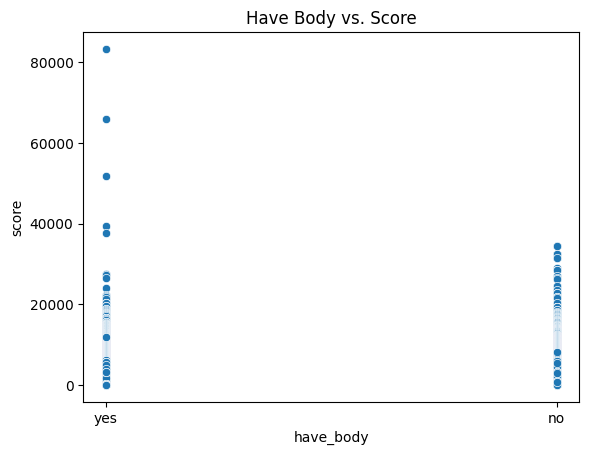

In [10]:
# From the table, we can see that there are null values in body and tag. This means these are the posts that have only title. Check how the null values are 
# impacting the scores they are are useful as some people only write posts with title. 
# Rows with Null values in body almost represent 40% of the data. These rows are posts with only title and should not be removed/ignored during analysis.

data['have_body'] = data['body'].apply(lambda x: 'yes' if pd.notnull(x) else 'no')
data.head()

# Plot title length vs. score
sns.scatterplot(x=data["have_body"], y=data["score"])
plt.title("Have Body vs. Score")
plt.show()

# From the plot we can confirm that having body is not necessary for getting a good score. But have_body may not be a suitable metric to understand this.

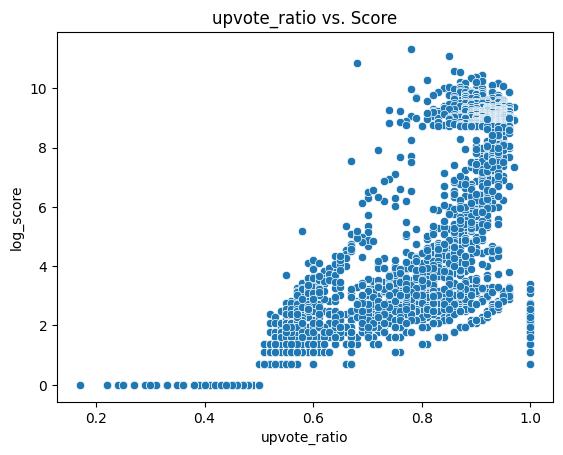

In [11]:
# Understanding the scores and upvote_ratio.

# Plot upvote_ratio vs. score
sns.scatterplot(x=data["upvote_ratio"], y=data["log_score"])
plt.title("upvote_ratio vs. Score")
plt.show()

# From the scatter plot we can see that upvote_ratio plays a significant role in determing the score, as the ratio closer to 1 indicates better scores.
# upvote_ratio is a potential feature to consider while generating scores.

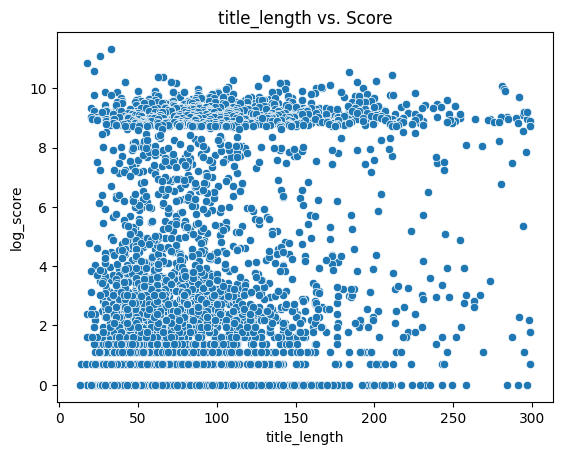

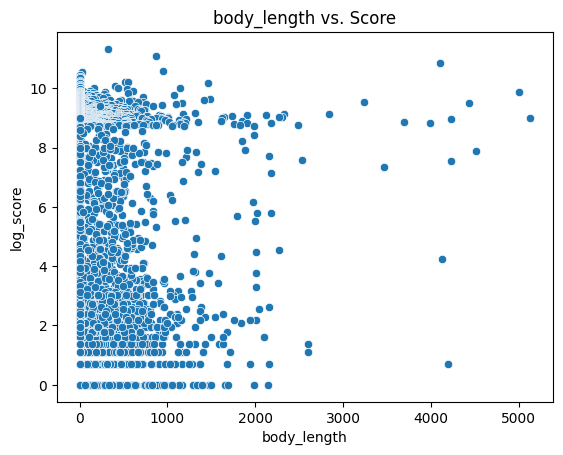

In [12]:
# Understanding title length and body length and how they impact the scores
data['title_length'] = [len(x) for x in data["title"]]
data['body_length'] = [len(x) if pd.notnull(x) else 0 for x in data["body"]]

# Plot title_length vs. score
sns.scatterplot(x=data["title_length"], y=data["log_score"])
plt.title("title_length vs. Score")
plt.show()

# Plot body_length vs. score
sns.scatterplot(x=data["body_length"], y=data["log_score"])
plt.title("body_length vs. Score")
plt.show()

In [13]:
correlation = data['title_length'].corr(data['log_score'])
print(correlation)

correlation = data['body_length'].corr(data['log_score'])
correlation

0.2530674406060393


np.float64(-0.11785833002783765)

In [14]:
# From both the plots we can see that body length has great impact on score, title length also has an impact on the score.

In [15]:
# Authors coloum - Trying to understand who have more posts
# From this we can see that deleted has a lot of counts. this means a lot original posting accounts have been deleted.
print(len(data['author'].unique())) # Total unique authors
author_counts = data['author'].value_counts()
author_counts = pd.DataFrame(author_counts)
author_counts

3314


,count
author,
DELETED,243
AskScienceModerator,47
inquilinekea,12
PHealthy,6
Gargatua13013,6
...,...
evogenome,1
initialsdrummer,1
SkipB94,1


C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_18456\17313963.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['author_post_count'] = data['author'].replace(author_counts.index, author_counts['count'])


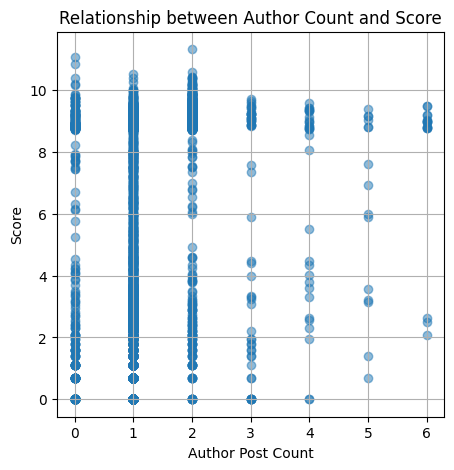

In [16]:
# Trying to understand if number of posts from one account will make difference on the score. Replacing the authors with author_post_count. Since most 
# general count of is below 6, setting other author_post_count for deleted, AskScienceModerator, inquilineke authors posts to 0 for analysis.

author_counts.loc[author_counts['count'] > 6, 'count'] = 0
data['author_post_count'] = data['author'].replace(author_counts.index, author_counts['count'])

plt.figure(figsize=(5, 5))
plt.scatter(data['author_post_count'], data['log_score'], alpha=0.5)
plt.title('Relationship between Author Count and Score')
plt.xlabel('Author Post Count')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [17]:
# Understand tags

# ANOVA test
f_stat, p_value = stats.f_oneway(*[data[data['tag'] == category]['score'] for category in data['tag'].unique()])

print(f"ANOVA F-statistic: {f_stat}")
print(f"ANOVA p-value: {p_value}")

# Tags column information
tag_describe = data.groupby('tag')['score'].describe()
tag_describe.sort_values('count', ascending=False)

# # From the ANOVA test, since p-value is less than 0.05, we can say that tag column has statistical impact on score. There are lot of tags with very 
# less counts (<10), combining all of them into 'Other' tag.
# Tags to combine include - ['  Linguistics', 'CERN AMA', 'Dog Cognition AMA','Earth Sciences and Biology', 'Ecology', 'First image of a black hole',
# 'Food', 'Interdisciplinary', 'META', 'Materials Science', 'Meta', 'Political Science']
tags_to_combine = tag_describe[tag_describe['count'] < 10].index

data['tag'] = data['tag'].replace(tags_to_combine, 'Other')
tag_describe_updated = data.groupby('tag')['score'].describe()
tag_describe_updated_sorted = tag_describe_updated.sort_values('count', ascending=False)
tag_describe_updated_sorted

C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_18456\2736961523.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*[data[data['tag'] == category]['score'] for category in data['tag'].unique()])


ANOVA F-statistic: nan
ANOVA p-value: nan


,count,mean,std,min,25%,50%,75%,max
tag,,,,,,,,
Biology,720.0,4029.101389,5599.100709,0.0,7.00,91.0,8011.75,32564.0
Physics,626.0,3318.388179,5758.658986,0.0,2.00,24.0,6936.50,65835.0
Human Body,452.0,4318.951327,5094.053244,0.0,7.00,952.5,8169.75,22720.0
Medicine,331.0,3137.102719,4546.491844,0.0,6.00,44.0,7114.00,20185.0
Earth Sciences,315.0,4656.387302,6049.425284,0.0,7.00,326.0,7833.50,37681.0
Astronomy,270.0,3900.755556,5171.418603,0.0,4.00,62.5,7250.50,23652.0
Chemistry,229.0,2671.558952,4586.258080,0.0,3.00,10.0,6488.00,24092.0
COVID-19,212.0,4325.075472,5936.405372,0.0,2.00,29.0,8511.00,26592.0
Engineering,189.0,4997.428571,6142.666488,0.0,5.00,2070.0,8722.00,31423.0


In [18]:
# Understand the datetime column
data['hour'] = data['datetime'].dt.hour
data['dayofweek'] = data['datetime'].dt.dayofweek  # Monday=0, Sunday=6
data['month'] = data['datetime'].dt.month

data.groupby('hour')['score'].describe()


,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,78.0,3549.743590,4966.246398,0.0,7.00,57.0,7582.75,18426.0
1,103.0,3398.679612,5025.259680,0.0,2.00,17.0,7413.00,15856.0
2,137.0,3503.759124,4439.851033,0.0,7.00,59.0,7261.00,14366.0
3,168.0,5016.041667,5383.697891,0.0,7.00,4615.5,8495.00,20348.0
4,235.0,5193.089362,5446.072810,0.0,10.00,6217.0,8162.50,26418.0
5,236.0,5014.038136,5584.226047,0.0,8.00,5152.5,8532.50,26348.0
6,273.0,5282.322344,6187.441716,0.0,9.00,3359.0,8575.00,34365.0
7,297.0,4085.569024,5198.998873,0.0,5.00,264.0,8010.00,28887.0
8,285.0,4813.470175,6185.446179,0.0,5.00,517.0,8720.00,37681.0


C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_18456\1630093024.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hour', y='log_score', data=data, estimator='mean', ci=None)


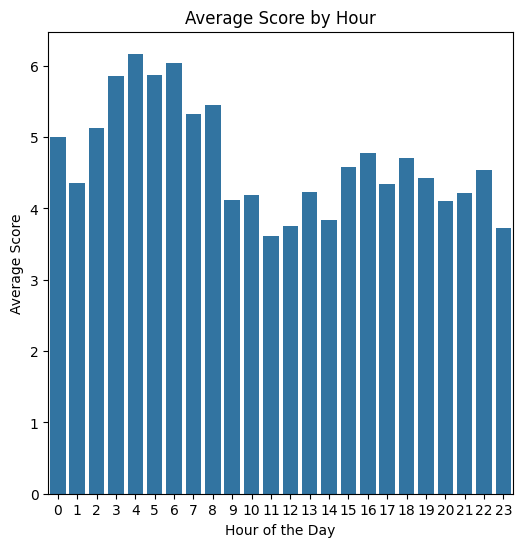

C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_18456\1630093024.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='dayofweek', y='log_score', data=data, estimator='mean', ci=None)


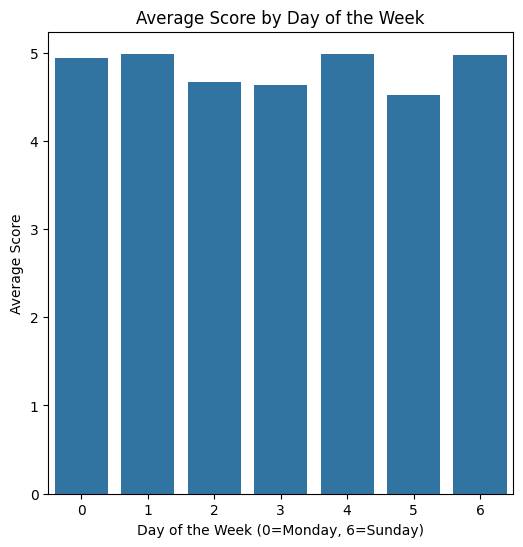

C:\Users\Sravya Ventrapragada\AppData\Local\Temp\ipykernel_18456\1630093024.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='month', y='log_score', data=data, estimator='mean', ci=None)


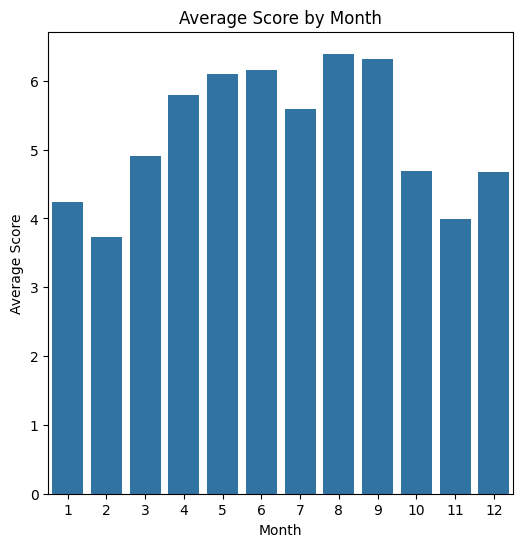

In [19]:
# Plot 1: Hour vs Score
plt.figure(figsize=(6, 6))
sns.barplot(x='hour', y='log_score', data=data, estimator='mean', ci=None)
plt.title('Average Score by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Score')
plt.show()

# Plot 2: Day of the Week vs Score
plt.figure(figsize=(6, 6))
sns.barplot(x='dayofweek', y='log_score', data=data, estimator='mean', ci=None)
plt.title('Average Score by Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Score')
plt.show()

# Plot 3: Month vs Score
plt.figure(figsize=(6, 6))
sns.barplot(x='month', y='log_score', data=data, estimator='mean', ci=None)
plt.title('Average Score by Month')
plt.xlabel('Month')
plt.ylabel('Average Score')
plt.show()


In [20]:
# Based on these plots, 3-8 hour has a peak engagement activity i.e., post counts, scores. Day of the week seems to have not much impact on the score. 
# Lastly, Month has some impact on score with 4 through 9 month. For analysis purpose I'm only considering the hour column.

In [21]:
# Understanding the sentiment od title and body columns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Title sentiment
data['title_sentiment'] = data['title'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
data['body_sentiment'] = data['body'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Define function to categorize sentiment
def sentiment_category(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply categorization to title and body sentiment
data['title_sentiment_category'] = data['title_sentiment'].apply(sentiment_category)
data['body_sentiment_category'] = data['body_sentiment'].apply(sentiment_category)


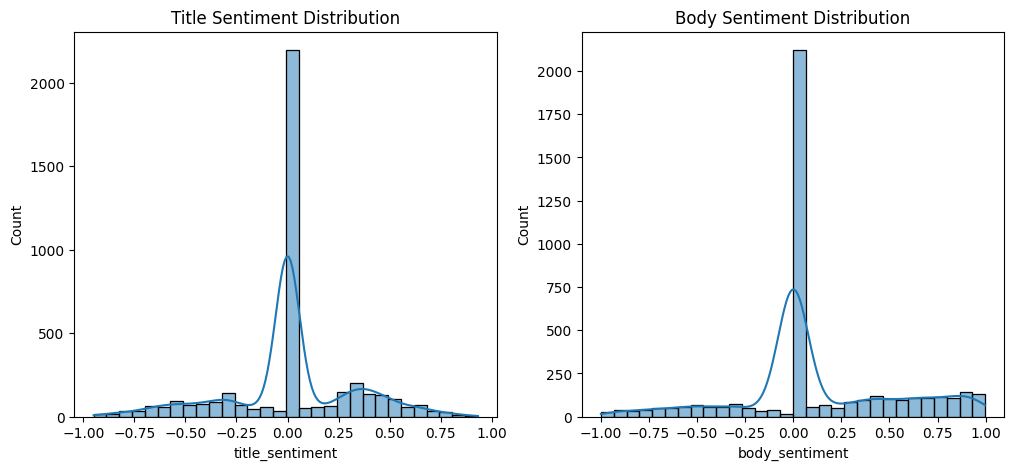

In [22]:
# Plot sentiment distribution for title and body
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['title_sentiment'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Title Sentiment Distribution')

sns.histplot(data['body_sentiment'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Body Sentiment Distribution')

plt.show()


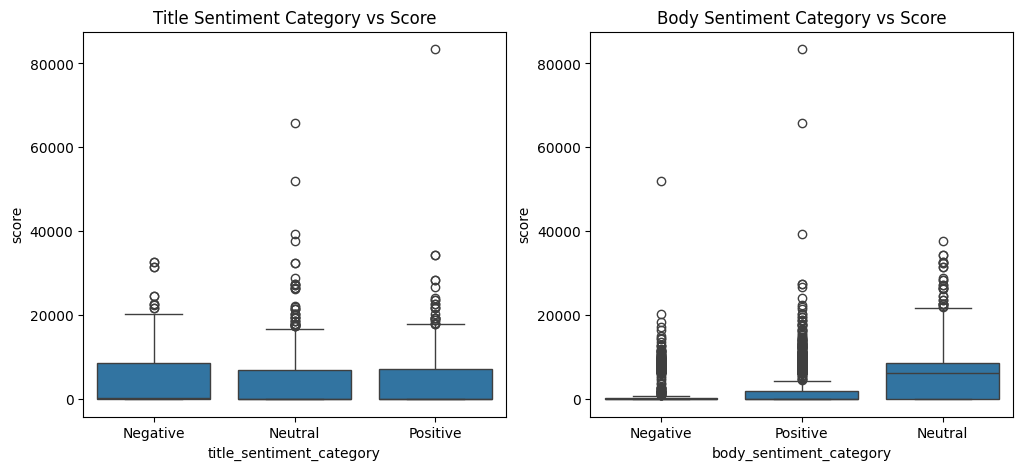

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Title Sentiment vs Score
plt.subplot(1, 2, 1)
sns.boxplot(x='title_sentiment_category', y='score', data=data)
plt.title("Title Sentiment Category vs Score")

# Body Sentiment vs Score
plt.subplot(1, 2, 2)
sns.boxplot(x='body_sentiment_category', y='score', data=data)
plt.title("Body Sentiment Category vs Score")

plt.show()


In [24]:
# Perform ANOVA for Title Sentiment
groups_title = [group["score"].values for name, group in data.groupby("title_sentiment_category")]
anova_title = f_oneway(*groups_title)

# Perform ANOVA for Body Sentiment
groups_body = [group["score"].values for name, group in data.groupby("body_sentiment_category")]
anova_body = f_oneway(*groups_body)

print(f"ANOVA for Title Sentiment: F-statistic = {anova_title.statistic:.3f}, p-value = {anova_title.pvalue:.3f}")
print(f"ANOVA for Body Sentiment: F-statistic = {anova_body.statistic:.3f}, p-value = {anova_body.pvalue:.3f}")


# From the box plots we can see that title sentiment doesnot have any impact on score whereas body sentiment has impact on score.

ANOVA for Title Sentiment: F-statistic = 16.272, p-value = 0.000
ANOVA for Body Sentiment: F-statistic = 163.000, p-value = 0.000


In [25]:
# Understanding title and body columns impact on score. For the text analysis we will use tf-idf scores, n-grams in tf-idf to understand words.
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(data['title'])
term_frequency_title = pd.DataFrame([vectorizer.get_feature_names_out(),tfidf_matrix.toarray().sum(axis=0)]).T
term_frequency_title.columns = ["term","count"]
term_frequency_title.sort_values("count",ascending=False)[0:20]

,term,count
2200,does,116.327402
2320,earth,43.799493
4113,like,43.423707
5095,people,40.359007
7581,water,39.506978
1730,covid,38.377711
896,body,34.66408
3970,know,33.671698
6458,space,33.139554
2062,did,32.004025


In [26]:
# With using single words, lot of topics are not being extracted. So using larger ngrams to caputer more word meaning
countvectorizer_title = CountVectorizer(ngram_range=(2,3),stop_words='english')
title_term_count = countvectorizer_title.fit_transform(data["title"])
term_frequency_title = pd.DataFrame([countvectorizer_title.get_feature_names_out(),title_term_count.toarray().sum(axis=0)]).T
term_frequency_title.columns = ["term","count"]
term_frequency_title.sort_values("count",ascending=False)[0:20]

,term,count
8931,covid 19,74
38408,speed light,34
4209,black hole,34
2843,askscience ama,31
2004,ama series,30
2845,askscience ama series,30
12372,does mean,28
11836,does body,22
24970,look like,21
12826,does water,18


In [27]:
countvectorizer_title = CountVectorizer(ngram_range=(3,4),stop_words='english')
title_term_count = countvectorizer_title.fit_transform(data["title"])
term_frequency_title = pd.DataFrame([countvectorizer_title.get_feature_names_out(),title_term_count.toarray().sum(axis=0)]).T
term_frequency_title.columns = ["term","count"]
term_frequency_title.sort_values("count",ascending=False)[0:20]

,term,count
2550,askscience ama series,30
3639,billion years old,7
7966,covid 19 vaccine,7
8873,deep sea creatures,6
21492,light years away,6
10510,does body know,6
29825,rate covid 19,6
19668,international space station,5
29765,random number generator,5
23853,million years ago,5


In [28]:
# From these we can see that lot of posts had AMA, covid 19, space(black hole, light years, space station) related. 
# For using these frequent topics I can create a key term, create a binary indicator column (1 if the term appears in the post, 0 otherwise).
# Another approach is to see calculate similarity score Using TF-Idata instead of using just individual words, compute the cosine similarity of each post 
# with a set of high-impact topics

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(data['title'])

# Create "topic" reference documents based on frequency counts from above
science_doc = "billion years old light years away international space station supermassive black holes"
covid_doc = "covid 19 vaccine rate covid 19 water germs organisms human"
random_doc = "random number generator long period time"

# Transform topic documents
science_vec = vectorizer.transform([science_doc])
covid_vec = vectorizer.transform([covid_doc])
random_vec = vectorizer.transform([random_doc])

# Compute cosine similarity
data['science_similarity'] = cosine_similarity(tfidf_matrix, science_vec).flatten()
data['covid_similarity'] = cosine_similarity(tfidf_matrix, covid_vec).flatten()
data['random_similarity'] = cosine_similarity(tfidf_matrix, random_vec).flatten()


In [30]:
data.columns

Index(['title', 'body', 'tag', 'datetime', 'author', 'score', 'upvote_ratio',
       'url', 'log_score', 'title_modified', 'body_modified', 'have_body',
       'title_length', 'body_length', 'author_post_count', 'hour', 'dayofweek',
       'month', 'title_sentiment', 'body_sentiment',
       'title_sentiment_category', 'body_sentiment_category',
       'science_similarity', 'covid_similarity', 'random_similarity'],
      dtype='object')

In [31]:
data.head()

,title,body,tag,datetime,author,score,upvote_ratio,url,log_score,title_modified,...,hour,dayofweek,month,title_sentiment,body_sentiment,title_sentiment_category,body_sentiment_category,science_similarity,covid_similarity,random_similarity
0,Post viral cough: why does it get worse after ...,Tl;dr: why is your cough during an upper respi...,Human Body,2022-12-09 02:52:07,CarboniferousCreek,1343.0,0.93,https://www.reddit.com/r/askscience/comments/z...,7.203406,Post viral cough: why does it get worse after ...,...,2,4,12,-0.0516,-0.8989,Negative,Negative,0.0,0.0,0.0
1,Can an x-ray of an adult show chronic malnouri...,If a person was chronically undernourished thr...,Human Body,2022-12-08 18:28:51,Foxs-In-A-Trenchcoat,426.0,0.91,https://www.reddit.com/r/askscience/comments/z...,6.056784,Can an x-ray of an adult show chronic malnouri...,...,18,3,12,0.0000,0.5362,Neutral,Positive,0.0,0.0,0.0
2,[META] Bots and AI tools on r/askscience,\n\nOver the past few days we have seen a sur...,Other,2022-12-08 09:04:25,AskScienceModerator,2218.0,0.92,https://www.reddit.com/r/askscience/comments/z...,7.704812,[META] Bots and AI tools on r/askscience,...,9,3,12,0.0000,-0.6486,Neutral,Negative,0.0,0.0,0.0
3,Can you predictably manipulate a magnetic gas?,Does there exist a gas that changes in respons...,Physics,2022-12-08 20:01:53,hufsa7,48.0,0.83,https://www.reddit.com/r/askscience/comments/z...,3.891820,Can you predictably manipulate a magnetic gas?,...,20,3,12,0.0000,0.8343,Neutral,Positive,0.0,0.0,0.0
4,Are there cells in humans (or other mammals) t...,NaN,Medicine,2022-12-09 01:11:34,Velym,14.0,0.89,https://www.reddit.com/r/askscience/comments/z...,2.708050,Are there cells in humans (or other mammals) t...,...,1,4,12,-0.4939,0.0000,Negative,Neutral,0.0,0.0,0.0


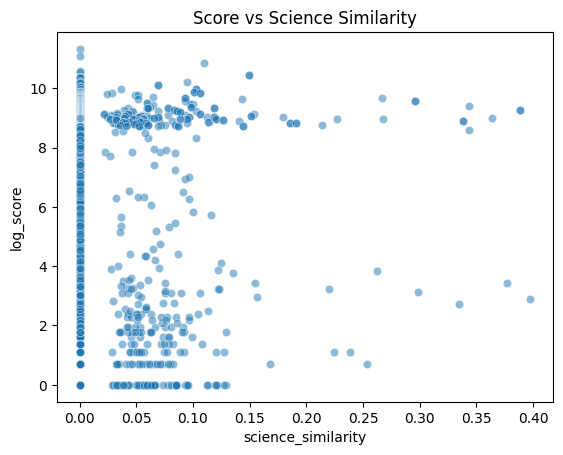

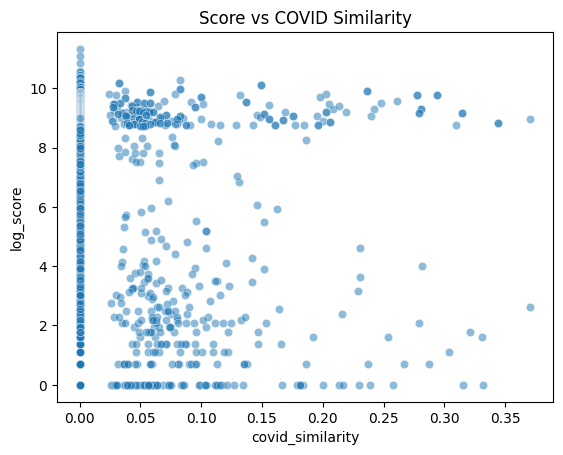

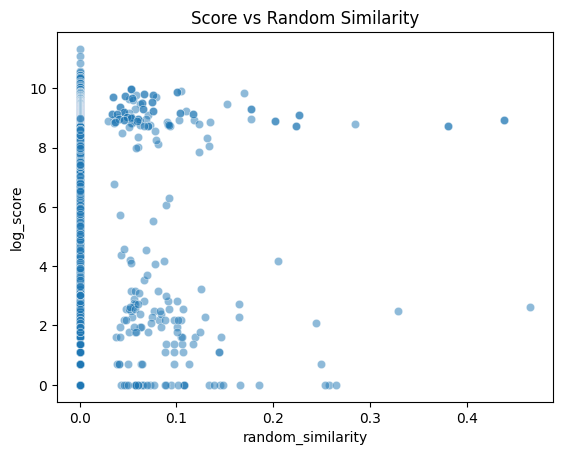

In [32]:
sns.scatterplot(x=data['science_similarity'], y=data['log_score'], alpha=0.5)
plt.title("Score vs Science Similarity")
plt.show()

sns.scatterplot(x=data['covid_similarity'], y=data['log_score'], alpha=0.5)
plt.title("Score vs COVID Similarity")
plt.show()

sns.scatterplot(x=data['random_similarity'], y=data['log_score'], alpha=0.5)
plt.title("Score vs Random Similarity")
plt.show()


In [33]:
from scipy.stats import f_oneway
# From these p-values, we can see taht science_similarity has significant vales, but I'm also considering the other two column as well.
# Define high and low score groups
high_score = data[data['score'] > data['score'].median()]
low_score = data[data['score'] <= data['score'].median()]

# Perform ANOVA for each similarity feature
for feature in ['science_similarity', 'covid_similarity', 'random_similarity']:
    stat, p_value = f_oneway(high_score[feature], low_score[feature])
    print(f"ANOVA for {feature}: p-value = {p_value:.5f}")

ANOVA for science_similarity: p-value = 0.00249
ANOVA for covid_similarity: p-value = 0.03916
ANOVA for random_similarity: p-value = 0.48931


In [34]:
# Modelling
# Initially starting with linear regression as baseline model later on moving to complex algorithms like Random Forest Regressor and XGBoost Regressor.
# Target is to predict the log_score value, Using MSE as evaluation metric.

In [35]:
data.columns

Index(['title', 'body', 'tag', 'datetime', 'author', 'score', 'upvote_ratio',
       'url', 'log_score', 'title_modified', 'body_modified', 'have_body',
       'title_length', 'body_length', 'author_post_count', 'hour', 'dayofweek',
       'month', 'title_sentiment', 'body_sentiment',
       'title_sentiment_category', 'body_sentiment_category',
       'science_similarity', 'covid_similarity', 'random_similarity'],
      dtype='object')

In [36]:
# Drop Unnecessary Columns
['title', 'body', 'url', 'author', 'datetime','month', 'dayofweek']

features = [
    'upvote_ratio', 'title_length', 'body_length', 'author_post_count', 'hour', 'month',
    'title_sentiment', 'body_sentiment', 'science_similarity', 'covid_similarity', 'random_similarity',
    'have_body'
]
target = 'log_score' 

# Handling any missing values
print(data.shape)
data = data.dropna(subset=[target])  # Drop rows where score is missing
data[features] = data[features].fillna(0)  # Fill missing feature values with 0 - but no missing values

# Categorical Features - dummy values
data = pd.get_dummies(data, columns=['tag', 'title_sentiment_category', 'body_sentiment_category'], drop_first=True)
data['have_body'] = data['have_body'].map({'yes': 1, 'no': 0})


(4169, 25)


In [37]:
# Test Train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data[features], data[target], test_size=0.2, random_state=42)


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MAE: {mae_lr}, RMSE: {rmse_lr}, R²: {r2_lr}")

Linear Regression - MAE: 1.4228938671793554, RMSE: 1.8848759078836197, R²: 0.7320131588350641


In [39]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_lr)
print(f"Random Forest - MAE: {mae_rf}, RMSE: {rmse_rf}, R²: {r2_rf}")


# XGBoost Model
X_train, X_test, y_train, y_test = train_test_split(data[features], data[target], test_size=0.2, random_state=42)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - MAE: {mae_xgb}, RMSE: {rmse_xgb}, R²: {r2_xgb}")


Random Forest - MAE: 0.7367321620832998, RMSE: 1.2875890072297071, R²: 0.7320131588350641
XGBoost - MAE: 0.753035438910235, RMSE: 1.2409522462402165, R²: 0.8838396045685409


In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, scoring='neg_mean_absolute_error', cv=3)
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")

# Use the best parameters found by GridSearchCV
best_model = grid.best_estimator_

# Fit the best model
best_model.fit(X_train, y_train)

# Make predictions
y_pred_best = best_model.predict(X_test)

# Evaluate the model
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
r2_best = r2_score(y_test, y_pred_best)

# Print the evaluation metrics
print(f"Best Model - MAE: {mae_best}, RMSE: {rmse_best}, R²: {r2_best}")

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best Model - MAE: 0.7591478634876214, RMSE: 1.2657018328375067, R²: 0.8791599877096432


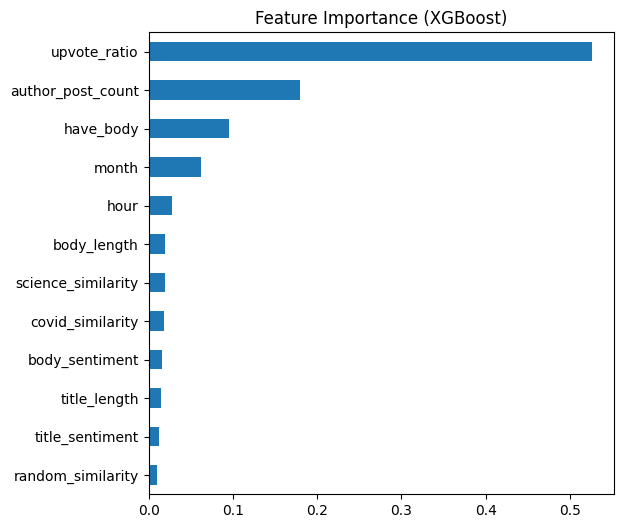

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(xgb_model.feature_importances_, index=features)
feature_importances.sort_values(ascending=True).plot(kind='barh', figsize=(6,6))
plt.title("Feature Importance (XGBoost)")
plt.show()
